[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vigne\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



BernoulliNB Accuracy: 0.8711
BernoulliNB Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.86       266
           1       0.86      0.90      0.88       277

    accuracy                           0.87       543
   macro avg       0.87      0.87      0.87       543
weighted avg       0.87      0.87      0.87       543

BernoulliNB Confusion Matrix:
 [[224  42]
 [ 28 249]]


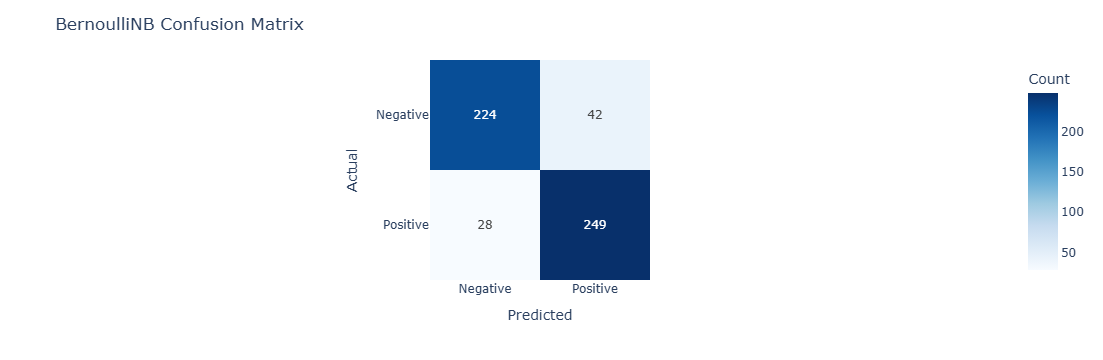

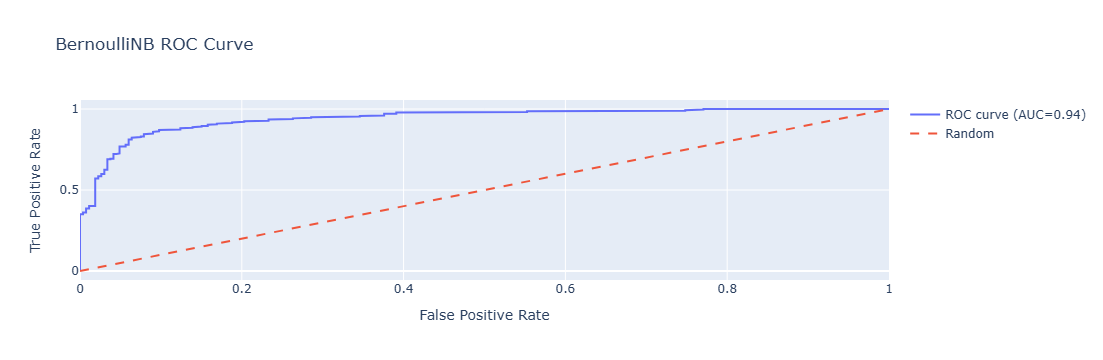


LinearSVC Accuracy: 0.9282
LinearSVC Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       266
           1       0.94      0.91      0.93       277

    accuracy                           0.93       543
   macro avg       0.93      0.93      0.93       543
weighted avg       0.93      0.93      0.93       543

LinearSVC Confusion Matrix:
 [[251  15]
 [ 24 253]]


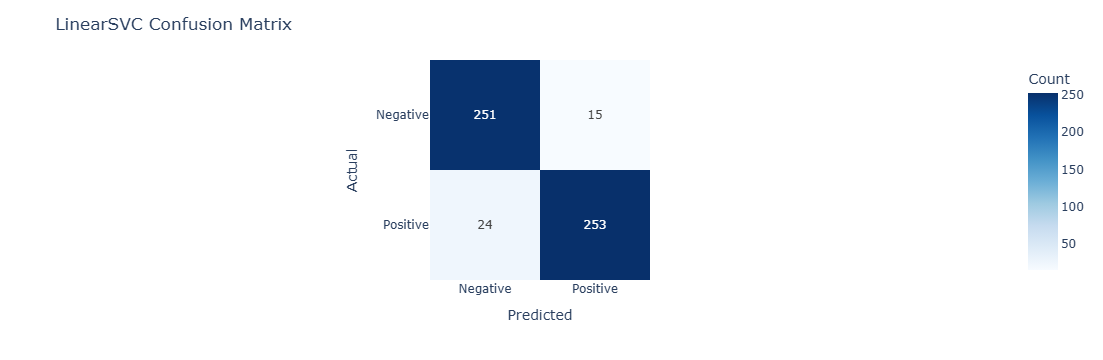

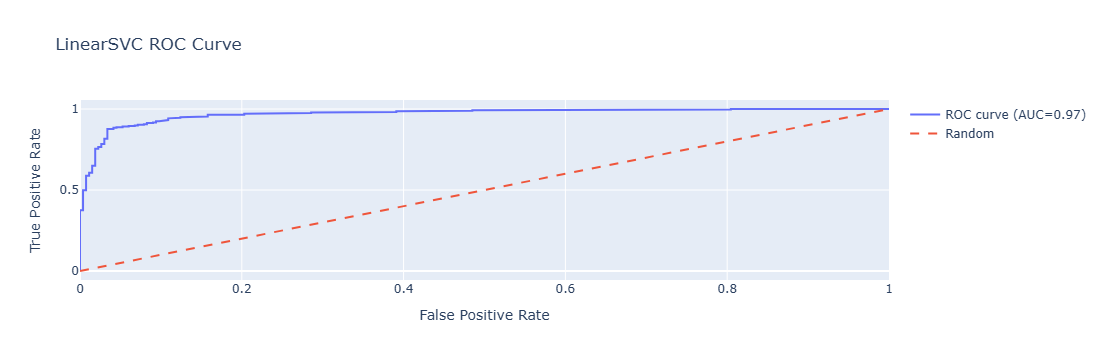


LogisticRegression Accuracy: 0.8692
LogisticRegression Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       266
           1       0.89      0.85      0.87       277

    accuracy                           0.87       543
   macro avg       0.87      0.87      0.87       543
weighted avg       0.87      0.87      0.87       543

LogisticRegression Confusion Matrix:
 [[237  29]
 [ 42 235]]


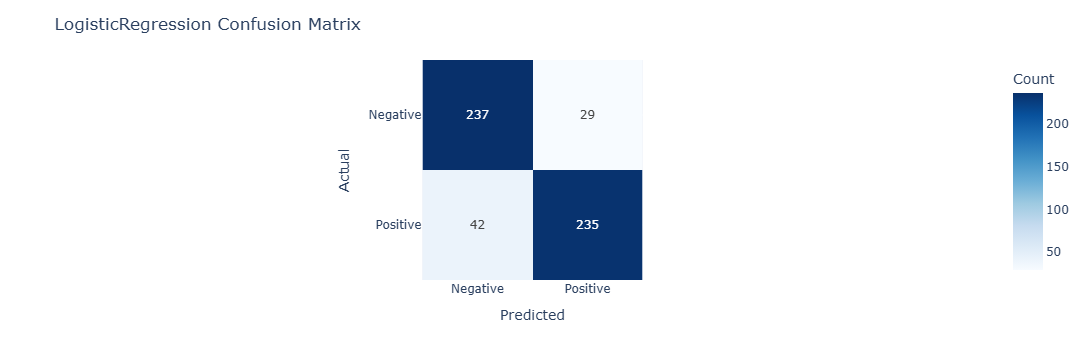

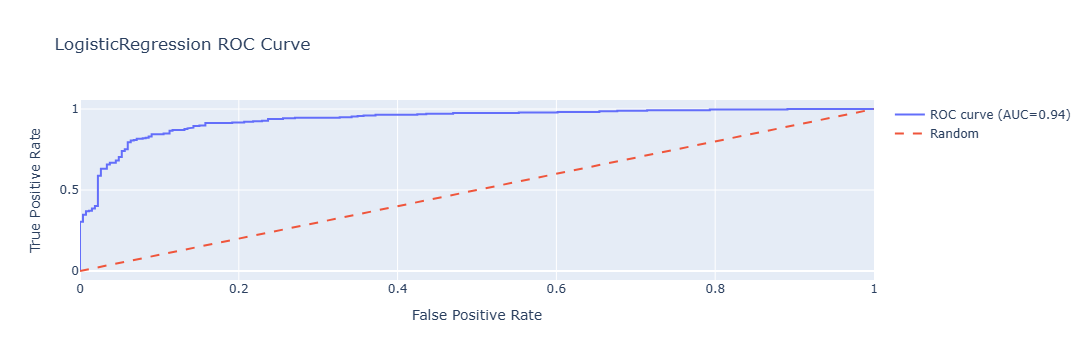


Model Accuracy Comparison:
BernoulliNB: 0.8711
LinearSVC: 0.9282
LogisticRegression: 0.8692


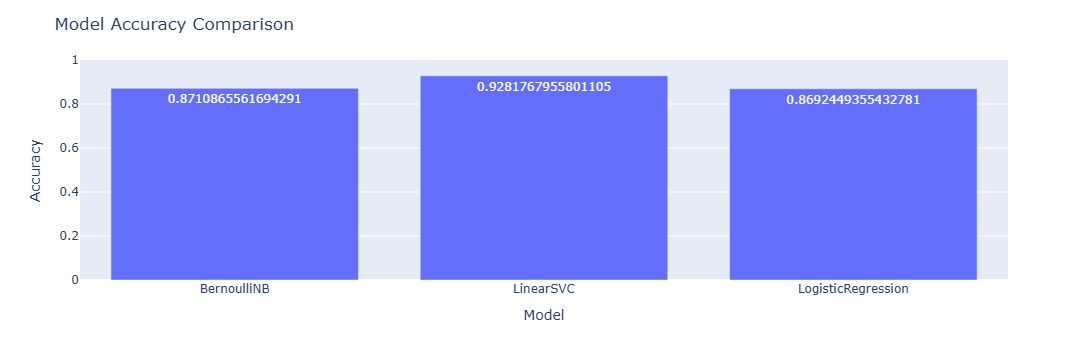

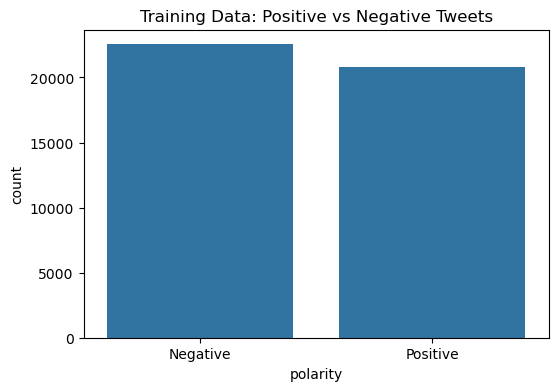

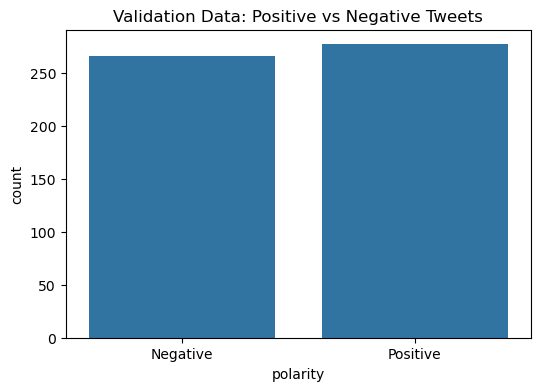

C:\Users\vigne\AppData\Local\Temp\ipykernel_15992\3744643352.py:180: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




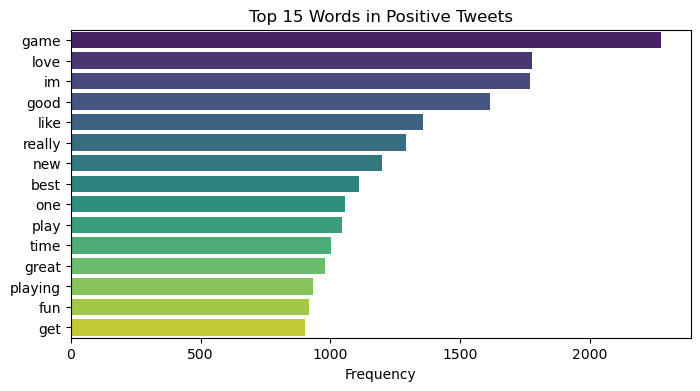

C:\Users\vigne\AppData\Local\Temp\ipykernel_15992\3744643352.py:180: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




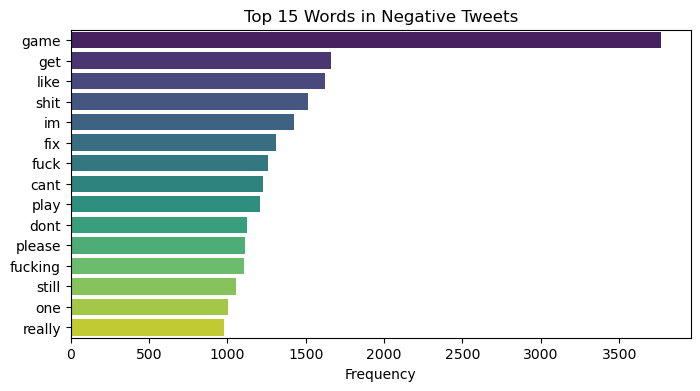

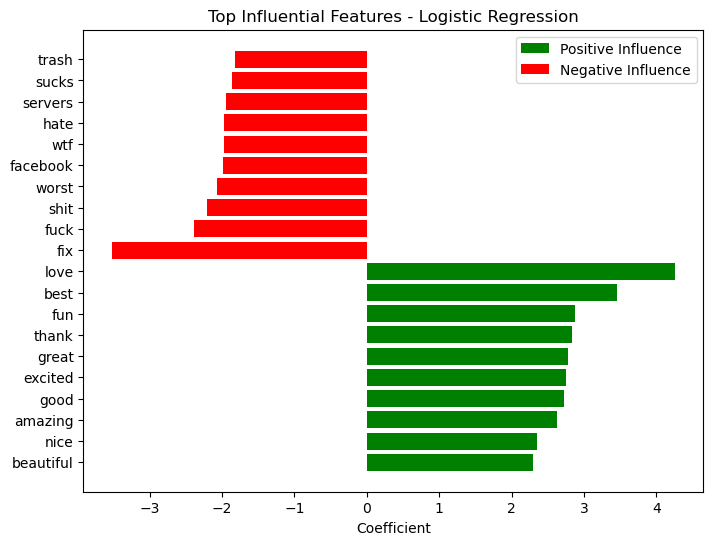


Sample Predictions:
BernoulliNB: [1 0 1]
LinearSVC: [1 0 1]
LogisticRegression: [1 0 1]


In [2]:
# -----------------------------
# Advanced Twitter Sentiment Analysis - Full Outputs + Visualizations
# -----------------------------

# Step 1: Install libraries if not installed
# !pip install pandas scikit-learn matplotlib seaborn nltk plotly

# -----------------------------
# Step 2: Imports
# -----------------------------
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# -----------------------------
# Step 3: Load datasets
# -----------------------------
train_path = r'C:\Users\vigne\Downloads\archive\twitter_training.csv'
valid_path = r'C:\Users\vigne\Downloads\archive\twitter_validation.csv'

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)

# -----------------------------
# Step 4: Rename columns & filter
# -----------------------------
train_df = train_df.rename(columns={train_df.columns[-1]: 'text', train_df.columns[2]: 'polarity'})
valid_df = valid_df.rename(columns={valid_df.columns[-1]: 'text', valid_df.columns[2]: 'polarity'})

train_df = train_df[train_df['polarity'].isin(['Positive','Negative'])]
valid_df = valid_df[valid_df['polarity'].isin(['Positive','Negative'])]

train_df['polarity'] = train_df['polarity'].map({'Negative':0, 'Positive':1})
valid_df['polarity'] = valid_df['polarity'].map({'Negative':0, 'Positive':1})

# -----------------------------
# Step 5: Text cleaning
# -----------------------------
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
valid_df['clean_text'] = valid_df['text'].apply(clean_text)

# -----------------------------
# Step 6: TF-IDF Vectorization
# -----------------------------
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_valid = vectorizer.transform(valid_df['clean_text'])

y_train = train_df['polarity']
y_valid = valid_df['polarity']

# -----------------------------
# Step 7: Train & Evaluate Models
# -----------------------------
def evaluate_model(model, name):
    # Train
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    
    # Print normal outputs
    acc = accuracy_score(y_valid, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_valid, y_pred))
    
    # Confusion matrix - normal
    print(f"{name} Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))
    
    # Confusion matrix - interactive
    cm = confusion_matrix(y_valid, y_pred)
    fig = px.imshow(cm, text_auto=True, color_continuous_scale='Blues',
                    labels=dict(x="Predicted", y="Actual", color="Count"),
                    x=['Negative','Positive'], y=['Negative','Positive'])
    fig.update_layout(title=f"{name} Confusion Matrix")
    fig.show()
    
    # ROC curve
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_valid)[:,1]
    else:
        from sklearn.calibration import CalibratedClassifierCV
        clf = CalibratedClassifierCV(model)
        clf.fit(X_train, y_train)
        y_score = clf.predict_proba(X_valid)[:,1]
    
    fpr, tpr, thresholds = roc_curve(y_valid, y_score)
    roc_auc = auc(fpr, tpr)
    
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC curve (AUC={roc_auc:.2f})'))
    fig2.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(dash='dash')))
    fig2.update_layout(title=f'{name} ROC Curve', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate')
    fig2.show()
    
    return acc

accuracy_dict = {}

# BernoulliNB
bnb = BernoulliNB()
accuracy_dict['BernoulliNB'] = evaluate_model(bnb, "BernoulliNB")

# LinearSVC with GridSearch
svc_params = {'C':[0.1,1,10]}
svm_grid = GridSearchCV(LinearSVC(max_iter=2000, dual=False), svc_params, cv=3, scoring='accuracy')
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_
accuracy_dict['LinearSVC'] = evaluate_model(best_svm, "LinearSVC")

# Logistic Regression with GridSearch
log_params = {'C':[0.1,1,10]}
log_grid = GridSearchCV(LogisticRegression(max_iter=500), log_params, cv=3, scoring='accuracy')
log_grid.fit(X_train, y_train)
best_log = log_grid.best_estimator_
accuracy_dict['LogisticRegression'] = evaluate_model(best_log, "LogisticRegression")

# -----------------------------
# Step 8: Accuracy Comparison - normal + interactive
# -----------------------------
# Normal
print("\nModel Accuracy Comparison:")
for k,v in accuracy_dict.items():
    print(f"{k}: {v:.4f}")

# Interactive bar
fig = px.bar(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), 
             labels={'x':'Model','y':'Accuracy'}, text=list(accuracy_dict.values()))
fig.update_layout(title="Model Accuracy Comparison", yaxis=dict(range=[0,1]))
fig.show()

# -----------------------------
# Step 9: Positive vs Negative Bars
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='polarity', data=train_df)
plt.xticks([0,1], ['Negative','Positive'])
plt.title("Training Data: Positive vs Negative Tweets")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='polarity', data=valid_df)
plt.xticks([0,1], ['Negative','Positive'])
plt.title("Validation Data: Positive vs Negative Tweets")
plt.show()

# -----------------------------
# Step 10: Top 15 Words - bar charts
# -----------------------------
def plot_top_words(df, label, title):
    words = ' '.join(df[df['polarity']==label]['clean_text']).split()
    most_common = Counter(words).most_common(15)
    words_list, counts = zip(*most_common)
    
    plt.figure(figsize=(8,4))
    sns.barplot(x=list(counts), y=list(words_list), palette="viridis")
    plt.title(title)
    plt.xlabel("Frequency")
    plt.show()

plot_top_words(train_df, 1, "Top 15 Words in Positive Tweets")
plot_top_words(train_df, 0, "Top 15 Words in Negative Tweets")

# -----------------------------
# Step 11: Feature Importance for Logistic Regression
# -----------------------------
feature_names = vectorizer.get_feature_names_out()
coef = best_log.coef_[0]
top_pos_idx = np.argsort(coef)[-10:]
top_neg_idx = np.argsort(coef)[:10]

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_pos_idx], coef[top_pos_idx], color='green', label='Positive Influence')
plt.barh(feature_names[top_neg_idx], coef[top_neg_idx], color='red', label='Negative Influence')
plt.title("Top Influential Features - Logistic Regression")
plt.xlabel("Coefficient")
plt.legend()
plt.show()

# -----------------------------
# Step 12: Sample Predictions
# -----------------------------
sample_tweets = [
    "I love this product, it's amazing!",
    "I hate this service, very bad experience.",
    "The movie was okay, not too good or bad."
]

sample_vec = vectorizer.transform(sample_tweets)

print("\nSample Predictions:")
print("BernoulliNB:", bnb.predict(sample_vec))
print("LinearSVC:", best_svm.predict(sample_vec))
print("LogisticRegression:", best_log.predict(sample_vec))
